#***Experiment 1***

In [ ]:
Netflix_Clustering = pd.get_dummies(Netflix_Clustering, columns=['type','country','rating'], drop_first=True)

In [ ]:
# Select your features wisely to avoid overfitting
Netflix_Clustering.drop(['description'], axis = 1, inplace = True)

In [ ]:
Netflix_Clustering.drop(['listed_in'], axis = 1, inplace = True)

In [ ]:
Netflix_Clustering.drop(['main_genre'], axis = 1, inplace = True)

In [ ]:
Netflix_Clustering.columns.to_list()

['release_year',
 'year_added',
 'month_added',
 'movie_duration',
 'tv_show_seasons',
 ' Anime Features',
 ' Children & Family Movies',
 ' Classic & Cult TV',
 ' Classic Movies',
 ' Comedies',
 ' Crime TV Shows',
 ' Cult Movies',
 ' Documentaries',
 ' Docuseries',
 ' Dramas',
 ' Faith & Spirituality',
 ' Horror Movies',
 ' Independent Movies',
 ' International Movies',
 ' International TV Shows',
 " Kids' TV",
 ' Korean TV Shows',
 ' LGBTQ Movies',
 ' Music & Musicals',
 ' Reality TV',
 ' Romantic Movies',
 ' Romantic TV Shows',
 ' Sci-Fi & Fantasy',
 ' Science & Nature TV',
 ' Spanish-Language TV Shows',
 ' Sports Movies',
 ' Stand-Up Comedy',
 ' Stand-Up Comedy & Talk Shows',
 ' TV Action & Adventure',
 ' TV Comedies',
 ' TV Dramas',
 ' TV Horror',
 ' TV Mysteries',
 ' TV Sci-Fi & Fantasy',
 ' TV Thrillers',
 ' Teen TV Shows',
 ' Thrillers',
 'Action & Adventure',
 'Anime Features',
 'Anime Series',
 'British TV Shows',
 'Children & Family Movies',
 'Classic & Cult TV',
 'Classic Mo

In [ ]:
Netflix_Clustering.columns = Netflix_Clustering.columns.str.strip()
Netflix_Clustering = Netflix_Clustering.loc[:,~Netflix_Clustering.columns.duplicated()]

In [ ]:
print("Netflix_Clustering shape:", Netflix_Clustering.shape)

Netflix_Clustering shape: (7777, 77)


In [ ]:
Netflix_Clustering.dtypes.value_counts()

,count
int64,45
bool,30
float64,2


In [ ]:
non_numeric_cols = Netflix_Clustering.select_dtypes(include=['object']).columns
print("Non-numeric columns:", list(non_numeric_cols))

Non-numeric columns: []


In [ ]:
Netflix_Clustering = Netflix_Clustering.apply(pd.to_numeric)

In [ ]:
Netflix_Clustering = Netflix_Clustering.astype(int)

In [ ]:
Netflix_Clustering.dtypes.value_counts()

,count
int64,77


In [ ]:
from scipy.sparse import csr_matrix, hstack
#convert to sparse matrix
structured_matrix = csr_matrix(Netflix_Clustering.values)
print("Structured matrix shape:", structured_matrix.shape)

Structured matrix shape: (7777, 77)


In [ ]:
# Step 6: Combine with NLP matrices
final_feature_matrix = hstack([
    structured_matrix,
    description_matrix,
    title_matrix,
    cast_matrix,
    director_matrix
])

print("Final combined feature matrix shape:", final_feature_matrix.shape)

Final combined feature matrix shape: (7777, 2527)


##***Dimensionality Reduction***

#####**We are going to use TruncatedSVD for Dimensionality Reduction as we have matrix of features**

In [ ]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=100, random_state=42)
X_svd_100 = svd.fit_transform(final_feature_matrix)

print("SVD matrix shape:", X_svd_100.shape)

SVD matrix shape: (7777, 100)


In [ ]:
svd_50 = TruncatedSVD(n_components=50, random_state=42)
X_svd_50 = svd_50.fit_transform(final_feature_matrix)
print("SVD matrix shape:", X_svd_50.shape)

SVD matrix shape: (7777, 50)


In [ ]:
svd_150 = TruncatedSVD(n_components=150, random_state=42)
X_svd_150 = svd_150.fit_transform(final_feature_matrix)
print("SVD matrix shape:", X_svd_150.shape)

SVD matrix shape: (7777, 150)


In [ ]:
print("Explained Variance:", svd.explained_variance_ratio_.sum())

Explained Variance: 0.9982046150680213


In [ ]:
print("Explained Variance:", svd_50.explained_variance_ratio_.sum())

Explained Variance: 0.9978242060109745


In [ ]:
print("Explained Variance:", svd_150.explained_variance_ratio_.sum())

Explained Variance: 0.9984611637397282


##### Do you think that dimensionality reduction is needed? Explain Why?

After applying encoding the shape of the dataset is - 7777 X 108. It will be difficult for clustering algorithms to handle these many features so we have to apply dimensionality reduction.

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

##***ML Model Implementation***

#### ML Model - 1

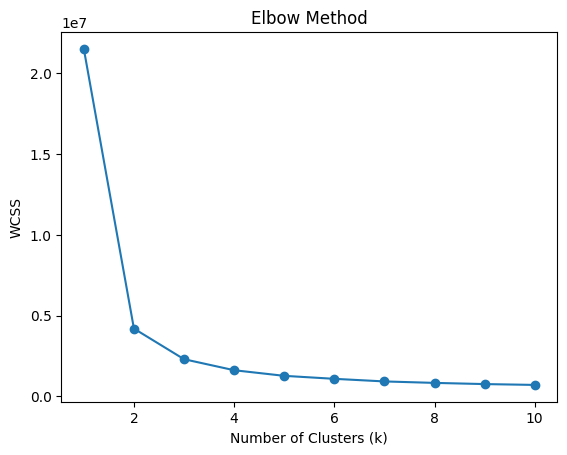

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_svd_100)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

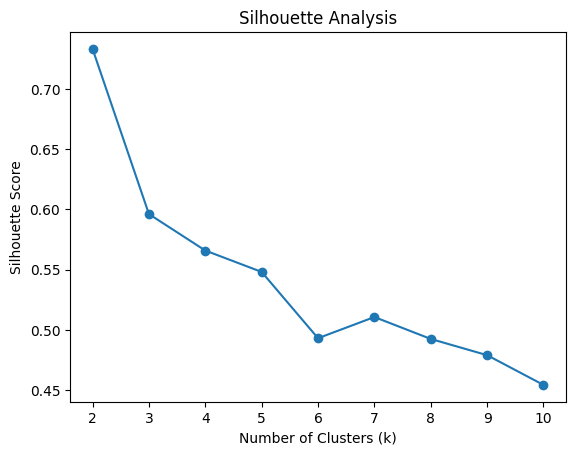

In [ ]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_svd_100)
    score = silhouette_score(X_svd_100, labels)
    scores.append(score)

import matplotlib.pyplot as plt

plt.plot(range(2,11), scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

In [ ]:
print(scores)

[np.float64(0.7330711484901368), np.float64(0.5960922316046204), np.float64(0.5658573453284308), np.float64(0.5481023965550654), np.float64(0.49313177500074484), np.float64(0.5107069909974038), np.float64(0.49252466805152484), np.float64(0.4790635066627029), np.float64(0.45439645386588406)]


In [ ]:
from sklearn.cluster import KMeans

# K = 2
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
Netflix_Clustering['Cluster_k2'] = kmeans_2.fit_predict(X_svd_100)

# K = 3
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
Netflix_Clustering['Cluster_k3'] = kmeans_3.fit_predict(X_svd_100)

# K = 4
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
Netflix_Clustering['Cluster_k4'] = kmeans_4.fit_predict(X_svd_100)

In [ ]:
print("K=2 Cluster Counts:")
print(Netflix_Clustering['Cluster_k2'].value_counts())

print("\nK=3 Cluster Counts:")
print(Netflix_Clustering['Cluster_k3'].value_counts())

print("\nK=4 Cluster Counts:")
print(Netflix_Clustering['Cluster_k4'].value_counts())

K=2 Cluster Counts:
Cluster_k2
1    5067
0    2710
Name: count, dtype: int64

K=3 Cluster Counts:
Cluster_k3
0    3603
1    2599
2    1575
Name: count, dtype: int64

K=4 Cluster Counts:
Cluster_k4
2    3192
1    2533
0    1087
3     965
Name: count, dtype: int64


In [ ]:
Netflix_Clustering.columns

Index(['release_year', 'year_added', 'month_added', 'movie_duration',
       'tv_show_seasons', 'Anime Features', 'Children & Family Movies',
       'Classic & Cult TV', 'Classic Movies', 'Comedies', 'Crime TV Shows',
       'Cult Movies', 'Documentaries', 'Docuseries', 'Dramas',
       'Faith & Spirituality', 'Horror Movies', 'Independent Movies',
       'International Movies', 'International TV Shows', 'Kids' TV',
       'Korean TV Shows', 'LGBTQ Movies', 'Music & Musicals', 'Reality TV',
       'Romantic Movies', 'Romantic TV Shows', 'Sci-Fi & Fantasy',
       'Science & Nature TV', 'Spanish-Language TV Shows', 'Sports Movies',
       'Stand-Up Comedy', 'Stand-Up Comedy & Talk Shows',
       'TV Action & Adventure', 'TV Comedies', 'TV Dramas', 'TV Horror',
       'TV Mysteries', 'TV Sci-Fi & Fantasy', 'TV Thrillers', 'Teen TV Shows',
       'Thrillers', 'Action & Adventure', 'Anime Series', 'British TV Shows',
       'Movies', 'TV Shows', 'type_TV Show', 'country_Brazil',
       'co

In [ ]:
Netflix_Clustering.groupby('Cluster_k3').agg({
    'movie_duration':'mean',
    'tv_show_seasons':'mean',
    'release_year':'mean'
})

,movie_duration,tv_show_seasons,release_year
Cluster_k3,,,
0,89.163197,0.00000,2014.008326
1,2.266641,1.62601,2016.070027
2,131.322540,0.00000,2010.248889


In [ ]:
Netflix_Clustering_features = Netflix_Clustering.drop(['Cluster_k2', 'Cluster_k3', 'Cluster_k4'], axis=1, errors = "ignore")

In [ ]:
Netflix_Clustering_features.columns

Index(['release_year', 'year_added', 'month_added', 'movie_duration',
       'tv_show_seasons', 'Anime Features', 'Children & Family Movies',
       'Classic & Cult TV', 'Classic Movies', 'Comedies', 'Crime TV Shows',
       'Cult Movies', 'Documentaries', 'Docuseries', 'Dramas',
       'Faith & Spirituality', 'Horror Movies', 'Independent Movies',
       'International Movies', 'International TV Shows', 'Kids' TV',
       'Korean TV Shows', 'LGBTQ Movies', 'Music & Musicals', 'Reality TV',
       'Romantic Movies', 'Romantic TV Shows', 'Sci-Fi & Fantasy',
       'Science & Nature TV', 'Spanish-Language TV Shows', 'Sports Movies',
       'Stand-Up Comedy', 'Stand-Up Comedy & Talk Shows',
       'TV Action & Adventure', 'TV Comedies', 'TV Dramas', 'TV Horror',
       'TV Mysteries', 'TV Sci-Fi & Fantasy', 'TV Thrillers', 'Teen TV Shows',
       'Thrillers', 'Action & Adventure', 'Anime Series', 'British TV Shows',
       'Movies', 'TV Shows', 'type_TV Show', 'country_Brazil',
       'co

In [ ]:
cluster_insights = Netflix_Clustering_features.groupby(Netflix_Clustering["Cluster_k3"]).mean().T

In [ ]:
cluster_insights[0].sort_values(ascending=False).head(15)

,0
year_added,2018.382182
release_year,2014.008326
movie_duration,89.163197
month_added,6.598113
country_United States,0.404940
rating_TV-MA,0.398002
International Movies,0.351929
country_Other,0.306134
rating_TV-14,0.182348
Independent Movies,0.137108


In [ ]:
cluster_insights[1].sort_values(ascending=False).head(15)

,1
year_added,2018.503270
release_year,2016.070027
month_added,6.985379
movie_duration,2.266641
tv_show_seasons,1.626010
type_TV Show,0.923432
rating_TV-MA,0.402078
country_United States,0.307426
rating_TV-14,0.261639
TV Dramas,0.246633


In [ ]:
cluster_insights[2].sort_values(ascending=False).head(15)

,2
year_added,2018.731429
release_year,2010.248889
movie_duration,131.322540
month_added,6.876190
International Movies,0.653968
country_India,0.414603
rating_TV-14,0.375238
country_Other,0.269841
rating_TV-MA,0.242540
Dramas,0.233016


#####**Insights for K=4**

In [ ]:
cluster_insights_2 = Netflix_Clustering_features.groupby(Netflix_Clustering["Cluster_k4"]).mean().T

In [ ]:
cluster_insights_2[0].sort_values(ascending=False).head(15)

,0
year_added,2018.689052
release_year,2009.101196
movie_duration,138.869365
month_added,6.970561
International Movies,0.694572
country_India,0.502300
rating_TV-14,0.415823
Dramas,0.257590
country_Other,0.233671
Action & Adventure,0.229071


In [ ]:
cluster_insights_2[1].sort_values(ascending=False).head(15)

,1
year_added,2018.515989
release_year,2016.180813
month_added,6.977102
tv_show_seasons,1.668377
movie_duration,1.247927
type_TV Show,0.947493
rating_TV-MA,0.408212
country_United States,0.300434
rating_TV-14,0.264508
TV Dramas,0.253060


In [ ]:
cluster_insights_2[2].sort_values(ascending=False).head(15)

,2
year_added,2018.550439
release_year,2013.678885
movie_duration,99.084900
month_added,6.573308
International Movies,0.426378
country_United States,0.357143
rating_TV-MA,0.356830
country_Other,0.348058
rating_TV-14,0.207080
rating_R,0.156955


In [ ]:
cluster_insights_2[3].sort_values(ascending=False).head(15)

,3
year_added,2018.024870
release_year,2014.339896
movie_duration,65.894301
month_added,6.762694
country_United States,0.505699
rating_TV-MA,0.456995
International Movies,0.198964
country_Other,0.176166
rating_TV-14,0.150259
rating_TV-PG,0.131606


**Insights:**

By training the above model on the clustering data after applying feature scaling and PCA, the model has divided the data into 2 clusters accurately, but it is clustering the data into 2 clusters we actually know i.e. Movies and TV Show, so the model has performed clustering correclty, but the insights are not at all useful for business decisions. This happened because we applied clustering on all the features in the dataset, which made the algorithm to divide it 2 known clusters. So now we need to drop features like type, movies_duration, TV_show duration etc. and only fed features like genre, rating, release year, country etc into the model.

### ML Model - 2

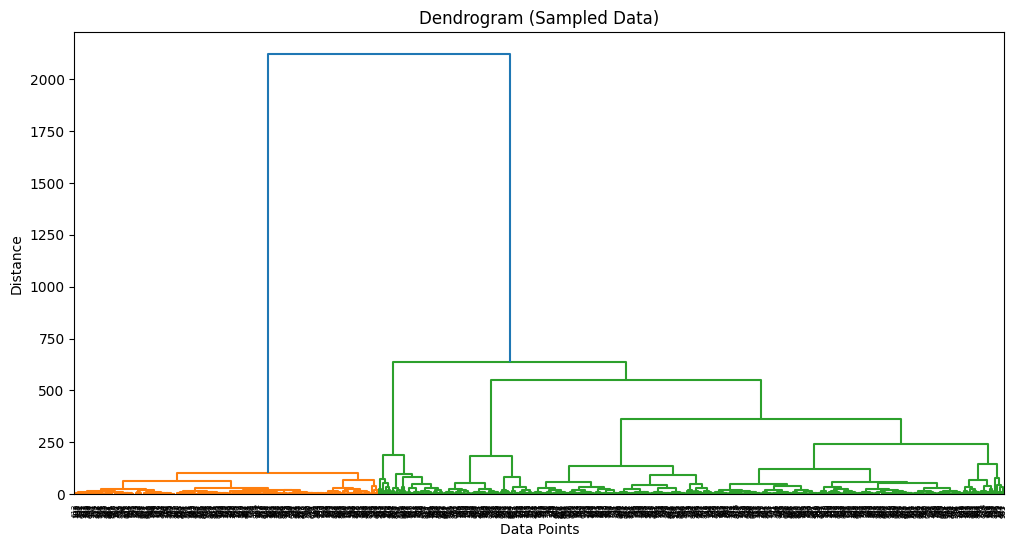

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
linkage_matrix = linkage(X_svd_100, method='ward')
sample_indices = np.random.choice(range(X_svd_100.shape[0]), size=1000, replace=False)
X_sample = X_svd_100[sample_indices]

linkage_sample = linkage(X_sample, method='ward')

plt.figure(figsize=(12,6))
dendrogram(linkage_sample)
plt.title("Dendrogram (Sampled Data)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

From this dendrogram, we can finalize that no. of clusters = 2

In [ ]:
Netflix_Clustering.columns

Index(['release_year', 'year_added', 'month_added', 'movie_duration',
       'tv_show_seasons', 'Anime Features', 'Children & Family Movies',
       'Classic & Cult TV', 'Classic Movies', 'Comedies', 'Crime TV Shows',
       'Cult Movies', 'Documentaries', 'Docuseries', 'Dramas',
       'Faith & Spirituality', 'Horror Movies', 'Independent Movies',
       'International Movies', 'International TV Shows', 'Kids' TV',
       'Korean TV Shows', 'LGBTQ Movies', 'Music & Musicals', 'Reality TV',
       'Romantic Movies', 'Romantic TV Shows', 'Sci-Fi & Fantasy',
       'Science & Nature TV', 'Spanish-Language TV Shows', 'Sports Movies',
       'Stand-Up Comedy', 'Stand-Up Comedy & Talk Shows',
       'TV Action & Adventure', 'TV Comedies', 'TV Dramas', 'TV Horror',
       'TV Mysteries', 'TV Sci-Fi & Fantasy', 'TV Thrillers', 'Teen TV Shows',
       'Thrillers', 'Action & Adventure', 'Anime Series', 'British TV Shows',
       'Movies', 'TV Shows', 'type_TV Show', 'country_Brazil',
       'co

In [ ]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=2,
    metric='euclidean',
    linkage='ward'
)

Netflix_Clustering['hc_cluster'] = hc.fit_predict(X_svd_100)

In [ ]:
silhouette_score(X_svd_100, Netflix_Clustering['hc_cluster'])

np.float64(0.7322890921010965)

In [ ]:
Netflix_Clustering['hc_cluster'].value_counts()

,count
hc_cluster,
0,5246
1,2531


In [ ]:
hc_cluster_insights = Netflix_Clustering_features.groupby(Netflix_Clustering["hc_cluster"]).mean().T

In [ ]:
hc_cluster_insights[0].sort_values(ascending=False).head(15)

,0
year_added,2018.481891
release_year,2012.783073
movie_duration,101.176325
month_added,6.691384
International Movies,0.439954
rating_TV-MA,0.348647
country_United States,0.341212
country_Other,0.292604
rating_TV-14,0.240183
country_India,0.162219


In [ ]:
hc_cluster_insights[1].sort_values(ascending=False).head(15)

,1
year_added,2018.517187
release_year,2016.325563
month_added,6.975504
tv_show_seasons,1.668906
movie_duration,1.267483
type_TV Show,0.947452
rating_TV-MA,0.407744
country_United States,0.299881
rating_TV-14,0.263927
TV Dramas,0.253260


#***Experiment 2***


In [ ]:
Exp_2N = Netflix_Clustering_exp2.copy()

In [ ]:
Exp_2N.head()

,type,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,main_genre
0,TV Show,Brazil,2020-08-14,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020.0,8.0,International TV Shows
1,Movie,Mexico,2016-12-23,2016,TV-MA,93,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016.0,12.0,Dramas
2,Movie,Singapore,2018-12-20,2011,R,78,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018.0,12.0,Horror Movies
3,Movie,United States,2017-11-16,2009,PG-13,80,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017.0,11.0,Action & Adventure
4,Movie,United States,2020-01-01,2008,PG-13,123,Dramas,A brilliant group of students become card-coun...,2020.0,1.0,Dramas


Although features such as type and duration may help separate content into structurally distinct groups, they primarily capture obvious format-level differences such as Movies vs TV Shows. Since the goal of this project was to uncover deeper content-based and business-relevant segmentation, these features were removed to reduce dominance of known distinctions and allow clustering to focus on richer metadata such as genres, ratings, countries, and release patterns.

In [ ]:
#Now we need to drop columns like type, duration so that clustring would not lead to 2 clusters
Exp_2N.drop(['type'], axis=1, inplace=True)

In [ ]:
#Dropping not required columns
Exp_2N.drop(['description', 'main_genre'], axis = 1, inplace = True)

In [ ]:
Exp_2N = pd.get_dummies(Exp_2N, columns=['country','rating'], drop_first=True)

In [ ]:
Exp_2N.shape

(7777, 106)

In [ ]:
Exp_2N.columns.to_list()

['release_year',
 'listed_in',
 'year_added',
 'month_added',
 ' Anime Features',
 ' Children & Family Movies',
 ' Classic & Cult TV',
 ' Classic Movies',
 ' Comedies',
 ' Crime TV Shows',
 ' Cult Movies',
 ' Documentaries',
 ' Docuseries',
 ' Dramas',
 ' Faith & Spirituality',
 ' Horror Movies',
 ' Independent Movies',
 ' International Movies',
 ' International TV Shows',
 " Kids' TV",
 ' Korean TV Shows',
 ' LGBTQ Movies',
 ' Music & Musicals',
 ' Reality TV',
 ' Romantic Movies',
 ' Romantic TV Shows',
 ' Sci-Fi & Fantasy',
 ' Science & Nature TV',
 ' Spanish-Language TV Shows',
 ' Sports Movies',
 ' Stand-Up Comedy',
 ' Stand-Up Comedy & Talk Shows',
 ' TV Action & Adventure',
 ' TV Comedies',
 ' TV Dramas',
 ' TV Horror',
 ' TV Mysteries',
 ' TV Sci-Fi & Fantasy',
 ' TV Thrillers',
 ' Teen TV Shows',
 ' Thrillers',
 'Action & Adventure',
 'Anime Features',
 'Anime Series',
 'British TV Shows',
 'Children & Family Movies',
 'Classic & Cult TV',
 'Classic Movies',
 'Comedies',
 'Cri

In [ ]:
#Columns names are getting duplicated
Exp_2N.columns = Exp_2N.columns.str.strip()

In [ ]:
Exp_2N = Exp_2N.loc[:,~Exp_2N.columns.duplicated()]

In [ ]:
Exp_2N.shape

(7777, 75)

In [ ]:
Exp_2N.columns.to_list()

['release_year',
 'listed_in',
 'year_added',
 'month_added',
 'Anime Features',
 'Children & Family Movies',
 'Classic & Cult TV',
 'Classic Movies',
 'Comedies',
 'Crime TV Shows',
 'Cult Movies',
 'Documentaries',
 'Docuseries',
 'Dramas',
 'Faith & Spirituality',
 'Horror Movies',
 'Independent Movies',
 'International Movies',
 'International TV Shows',
 "Kids' TV",
 'Korean TV Shows',
 'LGBTQ Movies',
 'Music & Musicals',
 'Reality TV',
 'Romantic Movies',
 'Romantic TV Shows',
 'Sci-Fi & Fantasy',
 'Science & Nature TV',
 'Spanish-Language TV Shows',
 'Sports Movies',
 'Stand-Up Comedy',
 'Stand-Up Comedy & Talk Shows',
 'TV Action & Adventure',
 'TV Comedies',
 'TV Dramas',
 'TV Horror',
 'TV Mysteries',
 'TV Sci-Fi & Fantasy',
 'TV Thrillers',
 'Teen TV Shows',
 'Thrillers',
 'Action & Adventure',
 'Anime Series',
 'British TV Shows',
 'Movies',
 'TV Shows',
 'country_Brazil',
 'country_Canada',
 'country_Egypt',
 'country_France',
 'country_India',
 'country_Japan',
 'country

In [ ]:
Exp_2N.drop('listed_in', axis=1, inplace=True)

In [ ]:
Exp_2N.shape

(7777, 74)

In [ ]:
Exp_2N.columns

Index(['release_year', 'year_added', 'month_added', 'Anime Features',
       'Children & Family Movies', 'Classic & Cult TV', 'Classic Movies',
       'Comedies', 'Crime TV Shows', 'Cult Movies', 'Documentaries',
       'Docuseries', 'Dramas', 'Faith & Spirituality', 'Horror Movies',
       'Independent Movies', 'International Movies', 'International TV Shows',
       'Kids' TV', 'Korean TV Shows', 'LGBTQ Movies', 'Music & Musicals',
       'Reality TV', 'Romantic Movies', 'Romantic TV Shows',
       'Sci-Fi & Fantasy', 'Science & Nature TV', 'Spanish-Language TV Shows',
       'Sports Movies', 'Stand-Up Comedy', 'Stand-Up Comedy & Talk Shows',
       'TV Action & Adventure', 'TV Comedies', 'TV Dramas', 'TV Horror',
       'TV Mysteries', 'TV Sci-Fi & Fantasy', 'TV Thrillers', 'Teen TV Shows',
       'Thrillers', 'Action & Adventure', 'Anime Series', 'British TV Shows',
       'Movies', 'TV Shows', 'country_Brazil', 'country_Canada',
       'country_Egypt', 'country_France', 'country_I

In [ ]:
Exp_2N.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7777 entries, 0 to 7786
Data columns (total 74 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   release_year                  7777 non-null   int64  
 1   year_added                    7777 non-null   float64
 2   month_added                   7777 non-null   float64
 3   Anime Features                7777 non-null   int64  
 4   Children & Family Movies      7777 non-null   int64  
 5   Classic & Cult TV             7777 non-null   int64  
 6   Classic Movies                7777 non-null   int64  
 7   Comedies                      7777 non-null   int64  
 8   Crime TV Shows                7777 non-null   int64  
 9   Cult Movies                   7777 non-null   int64  
 10  Documentaries                 7777 non-null   int64  
 11  Docuseries                    7777 non-null   int64  
 12  Dramas                        7777 non-null   int64  
 13  Faith & 

**“Although scaling is generally recommended for numerical features, in this case it degraded clustering performance due to the dominance of high-dimensional NLP features. Therefore, I retained the original feature scale to preserve meaningful distance relationships.”**

In [ ]:
# #Applying scaling on numeric columns
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()

# num_cols = ['release_year', 'year_added', 'month_added']

# scaler = StandardScaler()
# Exp_2N[num_cols] = scaler.fit_transform(Exp_2N[num_cols])


In [ ]:
Exp_2N.dtypes.value_counts()

,count
int64,43
bool,29
float64,2


In [ ]:
non_numeric_cols = Exp_2N.select_dtypes(include=['object']).columns
print("Non-numeric columns:", list(non_numeric_cols))

Non-numeric columns: []


In [ ]:
Exp_2N = Exp_2N.apply(pd.to_numeric)

In [ ]:
Exp_2N = Exp_2N.astype(int)

In [ ]:
Exp_2N.head()

,release_year,year_added,month_added,Anime Features,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,Crime TV Shows,Cult Movies,...,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR
0,2020,2020,8,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,2016,2016,12,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,2011,2018,12,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,2009,2017,11,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,2008,2020,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
Exp_2N.shape

(7777, 74)

In [ ]:
Exp_2N.dtypes.value_counts()

,count
int64,74


In [ ]:
from scipy.sparse import csr_matrix, hstack
#convert to sparse matrix
structured_matrix_2 = csr_matrix(Exp_2N.values)
print("Structured matrix shape:", structured_matrix_2.shape)

Structured matrix shape: (7777, 74)


In [ ]:
# Step 6: Combine with NLP matrices
final_feature_matrix_2 = hstack([
    structured_matrix_2,
    description_matrix,
    title_matrix,
    cast_matrix,
    director_matrix
])

print("Final combined feature matrix shape:", final_feature_matrix_2.shape)

Final combined feature matrix shape: (7777, 2524)


##***Dimensionality Reduction***

#####**We are going to use TruncatedSVD for Dimensionality Reduction as we have matrix of features**

In [ ]:
from sklearn.decomposition import TruncatedSVD

svd_2 = TruncatedSVD(n_components=100, random_state=42)
X_svd_100_2= svd_2.fit_transform(final_feature_matrix_2)

print("SVD matrix shape:", X_svd_100_2.shape)

SVD matrix shape: (7777, 100)


In [ ]:
svd_50_2 = TruncatedSVD(n_components=50, random_state=42)
X_svd_50_2 = svd_50_2.fit_transform(final_feature_matrix_2)
print("SVD matrix shape:", X_svd_50_2.shape)

SVD matrix shape: (7777, 50)


In [ ]:
svd_150_2 = TruncatedSVD(n_components=150, random_state=42)
X_svd_150_2 = svd_150_2.fit_transform(final_feature_matrix_2)
print("SVD matrix shape:", X_svd_150_2.shape)

SVD matrix shape: (7777, 150)


In [ ]:
print("Explained Variance:", svd_2.explained_variance_ratio_.sum())

Explained Variance: 0.9512498336009385


In [ ]:
print("Explained Variance:", svd_50_2.explained_variance_ratio_.sum())

Explained Variance: 0.9411261950185806


In [ ]:
print("Explained Variance:", svd_150_2.explained_variance_ratio_.sum())

Explained Variance: 0.9581831995527516


##### Do you think that dimensionality reduction is needed? Explain Why?

After applying encoding the shape of the dataset is - 7777 X 108. It will be difficult for clustering algorithms to handle these many features so we have to apply dimensionality reduction.

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

##***ML Model Implementation***

###ML Model - 1

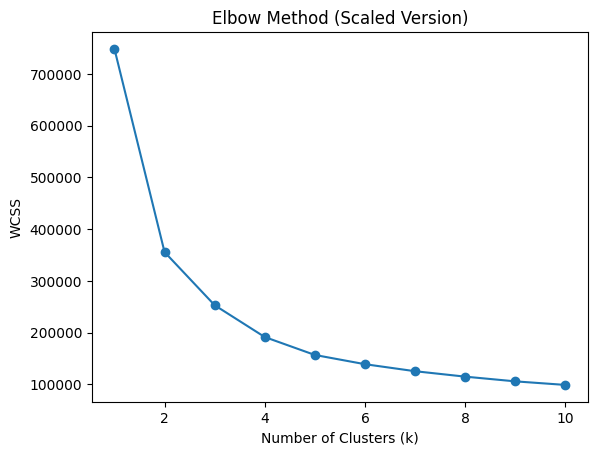

In [ ]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_svd_100_2)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method (Scaled Version)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

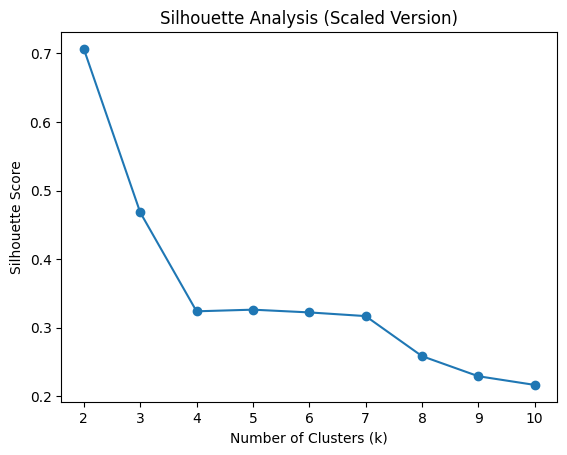

In [ ]:
from sklearn.metrics import silhouette_score

scores1 = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_svd_100_2)
    score = silhouette_score(X_svd_100_2, labels)
    scores1.append(score)

plt.plot(range(2, 11), scores1, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis (Scaled Version)")
plt.show()

In [ ]:
print(scores1)

[np.float64(0.706501048535263), np.float64(0.46824002972714623), np.float64(0.3239124609557251), np.float64(0.3263024294132102), np.float64(0.3223010403443552), np.float64(0.31693327536363086), np.float64(0.25853450639972), np.float64(0.22922556069412836), np.float64(0.2165737523045899)]


In [ ]:
from sklearn.cluster import KMeans

# k = 2
kmeans_2_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_2_2 = kmeans_2_2.fit_predict(X_svd_100_2)

# k = 3
kmeans_3_2 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_3_2 = kmeans_3_2.fit_predict(X_svd_100_2)

# k = 4
kmeans_4_2 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_4_2 = kmeans_4_2.fit_predict(X_svd_100_2)

In [ ]:
Exp_2N['Cluster_k2'] = labels_2_2
Exp_2N['Cluster_k3'] = labels_3_2
Exp_2N['Cluster_k4'] = labels_4_2

In [ ]:
print("K=2:\n", Netflix_Clustering['Cluster_k2'].value_counts())
print("\nK=3:\n", Netflix_Clustering['Cluster_k3'].value_counts())
print("\nK=4:\n", Netflix_Clustering['Cluster_k4'].value_counts())

K=2:
 Cluster_k2
1    5067
0    2710
Name: count, dtype: int64

K=3:
 Cluster_k3
0    3603
1    2599
2    1575
Name: count, dtype: int64

K=4:
 Cluster_k4
2    3192
1    2533
0    1087
3     965
Name: count, dtype: int64


In [ ]:
Exp_2N_features = Exp_2N.drop(['Cluster_k2', 'Cluster_k3', 'Cluster_k4'], axis=1, errors = "ignore")

In [ ]:
cluster_insights_n = Exp_2N_features.groupby(Exp_2N["Cluster_k3"]).mean().T

In [ ]:
cluster_insights_n[0].sort_values(ascending=False).head(15)

,0
year_added,2018.570743
release_year,2005.590727
month_added,6.483613
International Movies,0.341327
country_United States,0.338129
country_Other,0.269384
rating_TV-14,0.265388
country_India,0.201439
Action & Adventure,0.172662
rating_R,0.161471


In [ ]:
cluster_insights_n[1].sort_values(ascending=False).head(15)

,1
year_added,2018.486512
release_year,2017.115722
month_added,6.804310
rating_TV-MA,0.420750
country_United States,0.321788
International Movies,0.286832
country_Other,0.260335
rating_TV-14,0.240543
rating_TV-PG,0.102634
country_India,0.099282


In [ ]:
cluster_insights_n[2].sort_values(ascending=False).head(15)

,2
year_added,2018.287356
release_year,1977.609195
month_added,7.731801
country_United States,0.421456
International Movies,0.379310
rating_TV-14,0.340996
Dramas,0.283525
country_Other,0.260536
Action & Adventure,0.237548
country_India,0.187739


Cluster Insights for K=4

In [ ]:
cluster_insights_n_2 = Exp_2N_features.groupby(Exp_2N["Cluster_k4"]).mean().T

In [ ]:
cluster_insights_n_2[0].sort_values(ascending=False).head(15)

,0
year_added,2018.350902
release_year,2016.894586
month_added,9.683758
rating_TV-MA,0.390719
country_United States,0.320252
International Movies,0.282727
country_Other,0.268977
rating_TV-14,0.246921
rating_TV-PG,0.111429
country_India,0.107706


In [ ]:
cluster_insights_n_2[1].sort_values(ascending=False).head(15)

,1
year_added,2018.331967
release_year,1976.676230
month_added,7.737705
country_United States,0.413934
International Movies,0.393443
rating_TV-14,0.356557
Dramas,0.295082
country_Other,0.262295
Action & Adventure,0.250000
country_India,0.200820


In [ ]:
cluster_insights_n_2[2].sort_values(ascending=False).head(15)

,2
year_added,2018.643285
release_year,2016.874003
month_added,3.444149
rating_TV-MA,0.434840
country_United States,0.322473
International Movies,0.291888
country_Other,0.252992
rating_TV-14,0.236037
Independent Movies,0.101729
country_India,0.095412


In [ ]:
cluster_insights_n_2[3].sort_values(ascending=False).head(15)

,3
year_added,2018.576402
release_year,2004.192456
month_added,6.483559
International Movies,0.350097
country_United States,0.348162
country_Other,0.263056
rating_TV-14,0.260155
country_India,0.204062
Action & Adventure,0.177950
rating_R,0.170213


In [ ]:
cluster_summary = Exp_2N.groupby('Cluster_k4').mean()

In [ ]:
cluster_summary.T.sort_values(by=0, ascending=False).head(10)

Cluster_k4,0,1,2,3
year_added,2018.350902,2018.331967,2018.643285,2018.576402
release_year,2016.894586,1976.676230,2016.874003,2004.192456
month_added,9.683758,7.737705,3.444149,6.483559
Cluster_k3,0.965339,2.000000,0.962434,0.032882
rating_TV-MA,0.390719,0.127049,0.434840,0.152805
country_United States,0.320252,0.413934,0.322473,0.348162
International Movies,0.282727,0.393443,0.291888,0.350097
country_Other,0.268977,0.262295,0.252992,0.263056
rating_TV-14,0.246921,0.356557,0.236037,0.260155
rating_TV-PG,0.111429,0.155738,0.094415,0.089942


**Insights:**

Clustering helped segment Netflix content into distinct categories such as TV series, international movies, family-friendly films, and mature Hollywood movies. These clusters can help Netflix improve recommendation systems, guide content acquisition strategies, optimize marketing campaigns, and better personalize user experiences.

###ML Model - 2

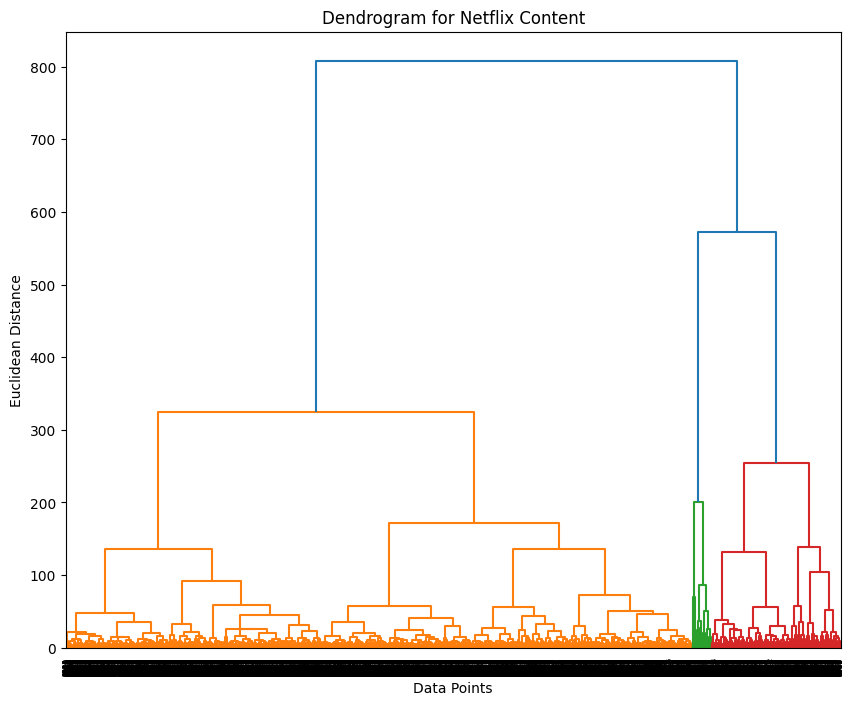

In [ ]:
# ML Model - 2 Implementation
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(10,8))  # MUST come first

dendrogram = sch.dendrogram(
    sch.linkage(X_svd_100_2, method='ward')
)

plt.title('Dendrogram for Netflix Content')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')

plt.show()
# Fit the Algorithm

# Predict on the model

From this dendrogram, we can finalize that no. of clusters = 3

In [ ]:
#Model Implementation
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=3,
    metric = 'euclidean',
    linkage='ward'
)

Exp_2N['hc_cluster'] = hc.fit_predict(X_svd_100_2)

In [ ]:
silhouette_score(X_svd_100_2, Exp_2N['hc_cluster'])

np.float64(0.48370278961392665)

In [ ]:
Exp_2N['hc_cluster'].value_counts()

,count
hc_cluster,
0,6292
1,1292
2,193


In [ ]:
cluster_understanding = Exp_2N_features.groupby(Exp_2N['hc_cluster']).mean().T

In [ ]:
cluster_understanding[0].sort_values(ascending=False).head(15)

,0
year_added,2018.475366
release_year,2017.080579
month_added,6.804514
rating_TV-MA,0.419580
country_United States,0.320089
International Movies,0.285760
country_Other,0.260648
rating_TV-14,0.242689
rating_TV-PG,0.103306
country_India,0.099332


In [ ]:
cluster_understanding[1].sort_values(ascending=False).head(15)

,1
year_added,2018.551084
release_year,2004.668731
month_added,6.569659
country_United States,0.360681
International Movies,0.340557
country_Other,0.264706
rating_TV-14,0.255418
country_India,0.197368
Action & Adventure,0.181889
rating_R,0.167183


In [ ]:
cluster_understanding[2].sort_values(ascending=False).head(15)

,2
year_added,2018.694301
release_year,1973.455959
month_added,7.544041
International Movies,0.440415
rating_TV-14,0.367876
country_United States,0.357513
Dramas,0.321244
country_Other,0.279793
Action & Adventure,0.259067
country_India,0.222798


“Hierarchical clustering suggested k=3 based on the dendrogram. However, the resulting clusters were highly imbalanced, with one dominant cluster containing most data points. In contrast, K-Means with k=4 produced more balanced and interpretable clusters, so it was selected as the final model.”

In [ ]:
import pickle
with open('kmeans_model.pkl', 'wb') as f:
  pickle.dump(kmeans_4_2, f)

In [ ]:
with open('svd_model.pkl', 'wb') as f:
    pickle.dump(svd_2, f)

In [ ]:
pickle.dump(description_vectorizer, open('desc_vectorizer.pkl', 'wb'))
pickle.dump(title_vectorizer, open('title_vectorizer.pkl', 'wb'))
pickle.dump(cast_vectorizer, open('cast_vectorizer.pkl', 'wb'))
pickle.dump(director_vectorizer, open('director_vectorizer.pkl', 'wb'))

#***✅ Conclusion: Model Selection***

**Two experiments** were conducted to evaluate the impact of including format-based features such as type in the clustering process. In the first experiment, type was retained along with NLP-derived features, while in the second experiment, it was removed to encourage more content-driven segmentation. Due to the strong influence of NLP features (description, title, cast, and director), both experiments produced very similar clustering structures, with comparable cluster distributions and overall patterns.

However, a closer inspection of cluster centroids revealed subtle but important differences. In Experiment 1, the presence of the type feature introduced a slight bias toward separating content based on format (Movies vs TV Shows). In contrast, Experiment 2, where type was removed, resulted in clusters that were more consistently driven by content attributes such as genre, maturity level, and thematic composition, rather than structural distinctions. This led to a marginal but meaningful improvement in the richness and interpretability of the clusters.

Therefore, although both approaches yielded comparable quantitative and structural results, the model from Experiment 2 was selected as the final approach. This decision was based on its ability to provide cleaner, more content-focused segmentation, better aligned with real-world use cases such as content recommendation and audience targeting, while avoiding reliance on obvious format-based separations.